In [1]:
from abc import ABC,abstractmethod
import cv2
import numpy as np
import pandas as pd
import trackpy as tp
from ultralytics import YOLO
import matplotlib.pyplot as plt
import trackpy as tp
from PIL import Image,ImageOps
import pims







In [ ]:
class TrackerBase(ABC):
    # @abstractmethod
    pass


In [ ]:
import trackpy as tp
from PIL import Image,ImageOps
import pims
import matplotlib.pyplot as plt
from ultralytics import YOLO


In [ ]:
image_path = './test_images/0003305.png'
image_path2 = './test_images/0002162.png'

video_path ='./videos/for_2.2.mp4'

img = Image.open(image_path)
@pims.pipeline
def grey(image):
    return image[:,:,1]
frames = grey(pims.open(image_path))


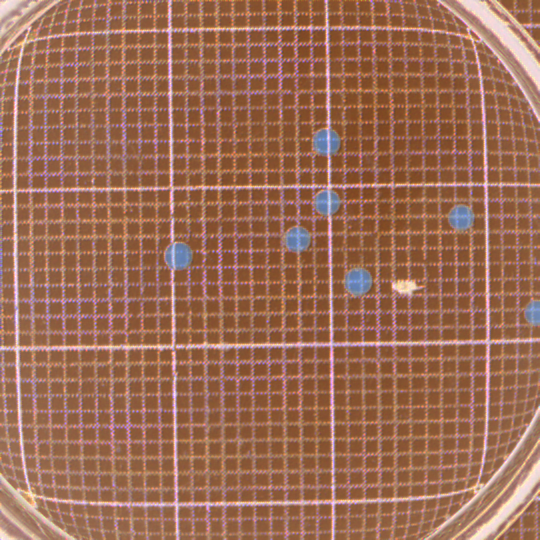

In [ ]:
img = Image.open(image_path2)
ImageOps.invert(img)


In [ ]:
model = YOLO('./weight/best.pt')



image 1/1 /mnt/g/Work/PROJECT-ALL/combine - Copy/test_images/0002162.png: 768x768 7 droplets, 11.3ms
Speed: 156.3ms preprocess, 11.3ms inference, 2.8ms postprocess per image at shape (1, 3, 768, 768)
342.23267
311.2748
281.004
446.34018
162.08214
308.93204
521.98157


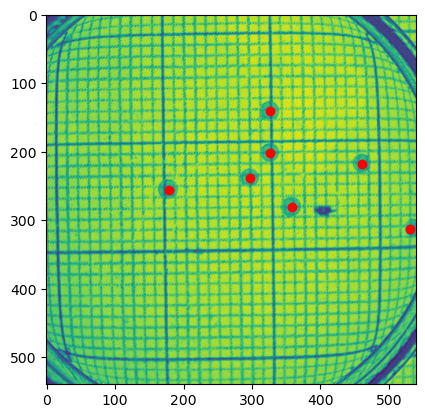

In [ ]:

pred = model.predict(image_path2)

# video_path ='./videos/for_2.2.mp4'
frames = grey(pims.open(image_path2))

for i in pred[0].boxes.xyxy.cpu().numpy():
    xc = i[0] + i[2]
    yc = i[1] + i[3]
    plt.imshow(frames[0])
    plt.scatter(xc/2,yc/2,c='r')
    # x1 ,y1 ,x2 , y2 
    
    print(i[0])


Frame([[[ 95, 144, 118],
        [ 76, 146, 118],
        [ 57, 107, 107],
        ...,
        [120, 172, 214],
        [118, 174, 214],
        [118, 177, 214]],

       [[ 84, 142, 118],
        [ 56, 114, 118],
        [ 29,  85, 107],
        ...,
        [122, 174, 214],
        [121, 173, 214],
        [120, 173, 214]],

       [[ 74, 102, 105],
        [ 37,  84, 106],
        [  0,  51,  94],
        ...,
        [123, 174, 214],
        [123, 173, 213],
        [123, 172, 212]],

       ...,

       [[120, 160, 186],
        [116, 161, 186],
        [113, 160, 177],
        ...,
        [116, 164, 204],
        [117, 165, 205],
        [116, 165, 205]],

       [[113, 158, 187],
        [111, 157, 188],
        [108, 161, 183],
        ...,
        [117, 163, 203],
        [118, 164, 204],
        [118, 162, 204]],

       [[113, 160, 189],
        [110, 158, 189],
        [108, 158, 190],
        ...,
        [117, 165, 201],
        [118, 165, 203],
        [118, 163, 204]]], dtype=uint8)
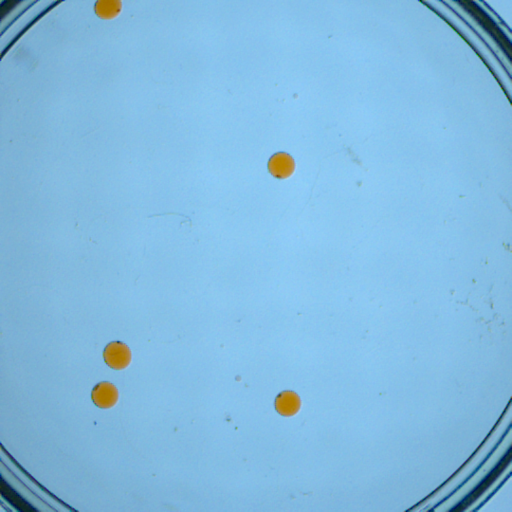

In [18]:
im = pims.open(image_path)[0]
im


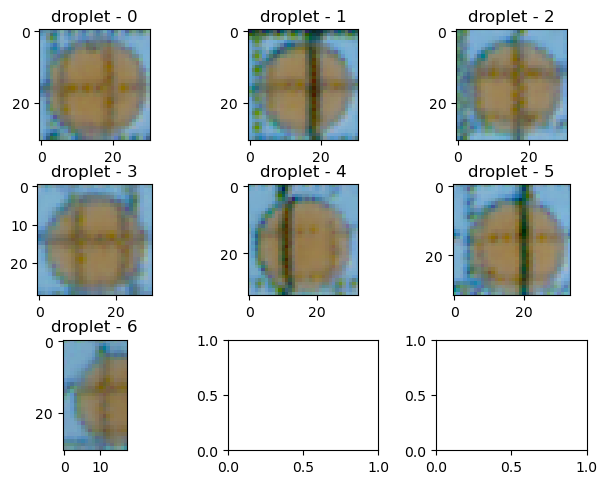

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
boxes = pred[0].boxes.xyxy.cpu().numpy()
fig,ax = plt.subplots(3,3)
ax = ax.flatten()
plt.tight_layout()
for idx ,box in enumerate(boxes):
    x1, y1, x2, y2 = box

    # convert to integers
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    # roi = frames[0][y1:y2, x1:x2]
    im = pims.open(image_path2)[0]
    
    plt.figure()
    ax[idx].set_title(f'droplet - {idx}')
    ax[idx].imshow(im[y1:y2, x1:x2])
    # plt.imshow(im[y1:y2, x1:x2])
    # plt.show()
plt.tight_layout()


In [ ]:
import cv2
import numpy as np
import pandas as pd
import trackpy as tp
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ----------------------------
# Load YOLO model
# ----------------------------
model = YOLO("./weight/best.pt")

video_path = "./videos/for_2.2.mp4"
# video_path = './test_images/0002162.png'

# image_path2 = './test_images/0002162.png'

cap = cv2.VideoCapture(video_path)

all_points = []

frame_no = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # ------------------------------------
    # YOLO detection
    # ------------------------------------
    pred = model.predict(frame, verbose=False)

    boxes = pred[0].boxes.xyxy.cpu().numpy()

    for box in boxes:

        x1, y1, x2, y2 = box

        # Convert to int
        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        # ------------------------------------
        # Optional padding
        # ------------------------------------
        pad = 5

        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)

        x2p = min(frame.shape[1], x2 + pad)
        y2p = min(frame.shape[0], y2 + pad)

        roi = frame[y1p:y2p, x1p:x2p]

        # Ignore empty ROIs
        if roi.size == 0:
            continue

        # ------------------------------------
        # Convert to grayscale
        # ------------------------------------
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # ------------------------------------
        # Background subtraction
        # Remove grid pattern approximately
        # ------------------------------------
        background = cv2.GaussianBlur(gray, (21, 21), 0)

        subtracted = cv2.subtract(background, gray)

        # ------------------------------------
        # Threshold
        # ------------------------------------
        _, binary = cv2.threshold(
            subtracted,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # ------------------------------------
        # Image moments
        # ------------------------------------
        M = cv2.moments(binary)

        if M["m00"] != 0:

            xc_roi = M["m10"] / M["m00"]
            yc_roi = M["m01"] / M["m00"]

            # Convert back to global coordinates
            xc = x1p + xc_roi
            yc = y1p + yc_roi

        else:
            # Fallback to YOLO center
            xc = (x1 + x2) / 2
            yc = (y1 + y2) / 2

        # ------------------------------------
        # Save coordinates
        # ------------------------------------
        all_points.append({
            "frame": frame_no,
            "x": xc,
            "y": yc,
        })

    frame_no += 1

cap.release()

# ------------------------------------
# Create DataFrame
# ------------------------------------
df = pd.DataFrame(all_points)

print(df.head())

# ------------------------------------
# Trackpy linking
# ------------------------------------
linked = tp.link(
    df,
    search_range=20,
    memory=2
)

print(linked.head())

# ------------------------------------
# Remove short trajectories
# ------------------------------------
linked = tp.filter_stubs(linked, threshold=20)

# ------------------------------------
# MSD
# ------------------------------------
msd = tp.imsd(
    linked,
    mpp=1,
    fps=1
)

print(msd.head())

df = msd.dropna(axis='columns')
for i in df.columns:
    print(i)
    
    plt.plot(df.index,df[i],label = f'droplet-{i}')
    plt.xlabel(fr'lag time $\tau$')
    plt.ylabel(fr'MSD[$\tau$]')
    
    plt.legend()


Frame 3362: 9 trajectories present.
   frame           x           y  particle
0      0  331.384858  177.186120         0
1      0  127.935733   33.928021         1
2      0  368.566845  357.737968         2
3      0  246.956522  177.153453         3
4      0  141.644295  227.758389         4
                    0         1         2         3         4         5   \
lag time [s]                                                               
1.0           0.370275  0.412591  0.313687  0.399899  0.316922  0.415432   
2.0           0.617661  0.742627  0.565303  0.760462  0.518973  0.762656   
3.0           0.889555  1.102850  0.802707  1.107740  0.737875  1.122076   
4.0           1.086956  1.533009  0.982199  1.346144  0.974539  1.368007   
5.0           1.301556  2.047902  1.173863  1.593313  1.242395  1.662076   

                    6         7         10        13        15        16  \
lag time [s]                                                               
1.0           0.35250

In [ ]:
msd.columns


Index([0, 1, 2, 3, 4, 5, 6, 7, 10, 13, 15, 16, 17], dtype='int64')

In [34]:
df = msd.dropna(axis='columns')
df


,0,1,2,3,4,5,6,7,10,15,16,17
lag time [s],,,,,,,,,,,,
1.0,0.370275,0.412591,0.313687,0.399899,0.316922,0.415432,0.352504,0.145695,0.593443,0.362953,0.156036,0.405152
2.0,0.617661,0.742627,0.565303,0.760462,0.518973,0.762656,0.685622,0.232639,0.971378,0.584661,0.228418,0.702284
3.0,0.889555,1.102850,0.802707,1.107740,0.737875,1.122076,1.026637,0.324195,1.374046,0.840743,0.283769,1.008492
4.0,1.086956,1.533009,0.982199,1.346144,0.974539,1.368007,1.287058,0.377976,1.883509,1.123434,0.319139,1.243521
5.0,1.301556,2.047902,1.173863,1.593313,1.242395,1.662076,1.553677,0.438188,2.292912,1.466897,0.350843,1.493775
...,...,...,...,...,...,...,...,...,...,...,...,...
96.0,116.454211,241.702010,92.854688,138.207906,132.641984,138.334635,130.431361,0.568419,60.288768,56.313008,0.711817,76.290876
97.0,118.585104,246.356770,94.544323,140.730692,135.063180,140.579948,132.724621,0.541401,61.222808,56.995951,0.713518,77.444645
98.0,120.720243,251.023533,96.238500,143.280929,137.493676,142.838380,135.044657,0.629255,62.183747,57.694700,0.718141,78.623566


In [ ]:
df.index


Index([  1.0,   2.0,   3.0,   4.0,   5.0,   6.0,   7.0,   8.0,   9.0,  10.0,
        11.0,  12.0,  13.0,  14.0,  15.0,  16.0,  17.0,  18.0,  19.0,  20.0,
        21.0,  22.0,  23.0,  24.0,  25.0,  26.0,  27.0,  28.0,  29.0,  30.0,
        31.0,  32.0,  33.0,  34.0,  35.0,  36.0,  37.0,  38.0,  39.0,  40.0,
        41.0,  42.0,  43.0,  44.0,  45.0,  46.0,  47.0,  48.0,  49.0,  50.0,
        51.0,  52.0,  53.0,  54.0,  55.0,  56.0,  57.0,  58.0,  59.0,  60.0,
        61.0,  62.0,  63.0,  64.0,  65.0,  66.0,  67.0,  68.0,  69.0,  70.0,
        71.0,  72.0,  73.0,  74.0,  75.0,  76.0,  77.0,  78.0,  79.0,  80.0,
        81.0,  82.0,  83.0,  84.0,  85.0,  86.0,  87.0,  88.0,  89.0,  90.0,
        91.0,  92.0,  93.0,  94.0,  95.0,  96.0,  97.0,  98.0,  99.0, 100.0],
      dtype='float64', name='lag time [s]')

0
1
2
3
4
5
6
7
10
15
16
17


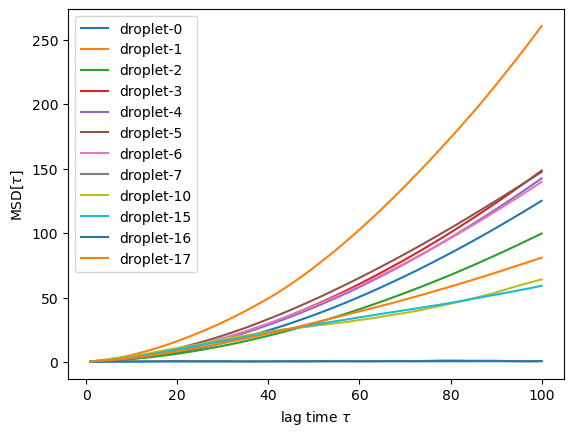

In [42]:
for i in df.columns:
    print(i)
    
    plt.plot(df.index,df[i],label = f'droplet-{i}')
    plt.xlabel(fr'lag time $\tau$')
    plt.ylabel(fr'MSD[$\tau$]')
    
    plt.legend()
    

In [ ]:
import cv2
from ultralytics import YOLO

model = YOLO('./weight/best.pt')

video_path = './videos/for_2.2.mp4'

cap = cv2.VideoCapture(video_path)

# Video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    'droplet_centers.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # YOLO prediction on this frame
    pred = model.predict(frame, verbose=False)

    # Draw red dots at box centers
    for box in pred[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = box

        xc = int((x1 + x2) / 2)
        yc = int((y1 + y2) / 2)

        cv2.circle(
            frame,
            (xc, yc),
            radius=5,
            color=(0, 0, 255),   # Red in OpenCV (BGR)
            thickness=-1
        )

    out.write(frame)

cap.release()
out.release()

print("Saved video as droplet_centers.mp4")


Saved video as droplet_centers.mp4


0

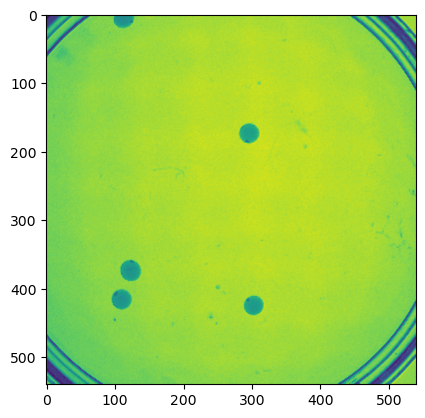

In [ ]:
plt.imshow(frames[0])
frames[0].frame_no


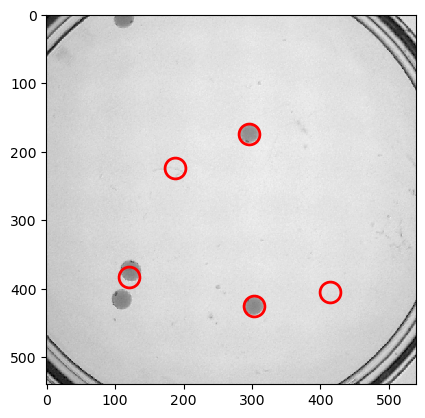

<AxesSubplot: >

In [ ]:
f = tp.locate(frames[0],91, invert=True)

tp.annotate(f,frames[0])


Frame 3950: 7 trajectories present.

First linked rows:
   frame           x           y  particle
0      0  293.712500  117.302500         0
1      0  404.492537  261.289552         1
2      0   58.269231  139.214286         2
3      0  375.564356  122.710396         3
4      0  335.769231  426.205128         4

Particles kept:
[0, 1, 3, 4, 5, 6, 7]

Number of trajectories after filtering: 7
Writing frame 0


Writing frame 100


Writing frame 200
Writing frame 300
Writing frame 400
Writing frame 500
Writing frame 600
Writing frame 700
Writing frame 800
Writing frame 900
Writing frame 1000
Writing frame 1100
Writing frame 1200
Writing frame 1300
Writing frame 1400
Writing frame 1500
Writing frame 1600
Writing frame 1700
Writing frame 1800
Writing frame 1900
Writing frame 2000
Writing frame 2100
Writing frame 2200
Writing frame 2300
Writing frame 2400
Writing frame 2500
Writing frame 2600
Writing frame 2700
Writing frame 2800
Writing frame 2900
Writing frame 3000
Writing frame 3100
Writing frame 3200
Writing frame 3300
Writing frame 3400
Writing frame 3500
Writing frame 3600
Writing frame 3700
Writing frame 3800
Writing frame 3900

Saved overlay video:
tracked_overlay.mp4

Track lengths:
particle
12       6
14      21
15      21
11      24
8       34
9       34
13      60
10     834
2     1438
3     3939
0     3951
1     3951
4     3951
5     3951
6     3951
7     3951
dtype: int64


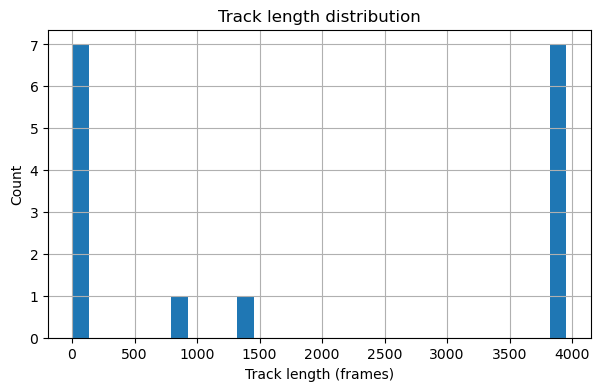


Particles kept:
[0, 1, 3, 4, 5, 6, 7]

Number of trajectories after filtering: 7


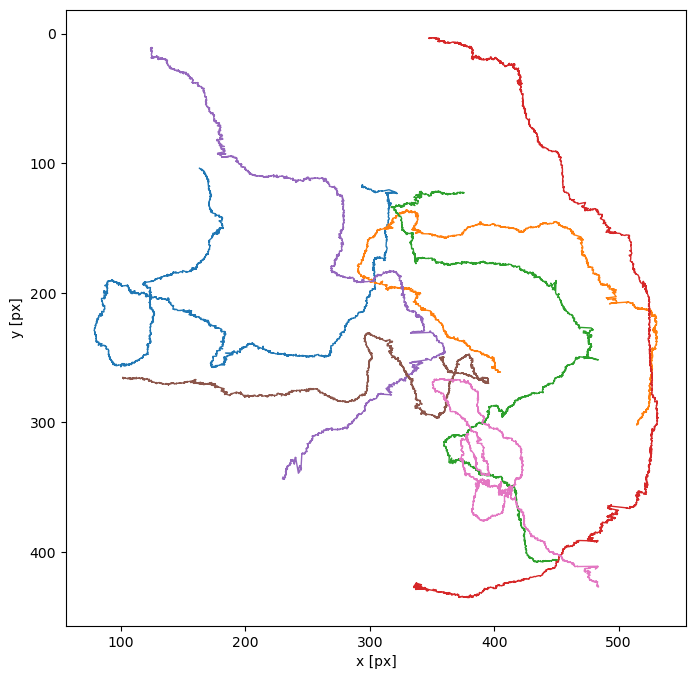

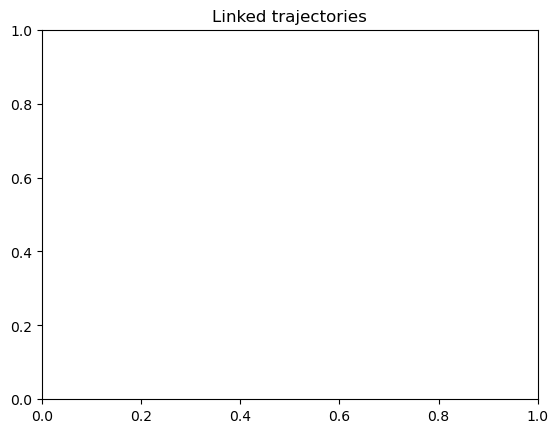


MSD columns:
[0, 1, 3, 4, 5, 6, 7]


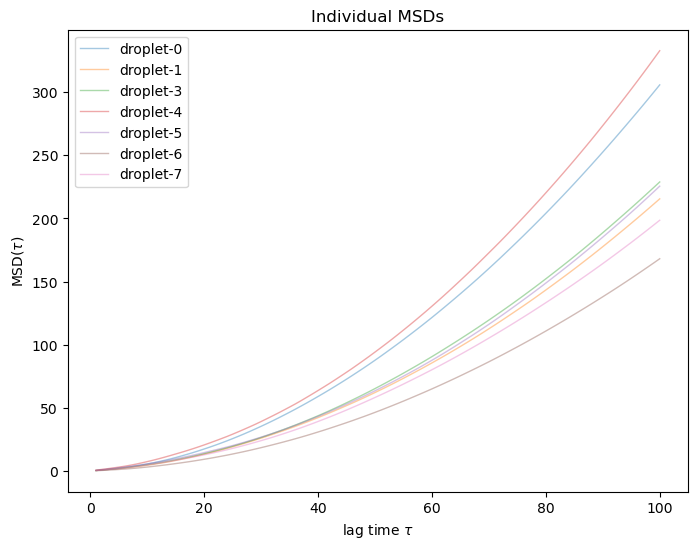

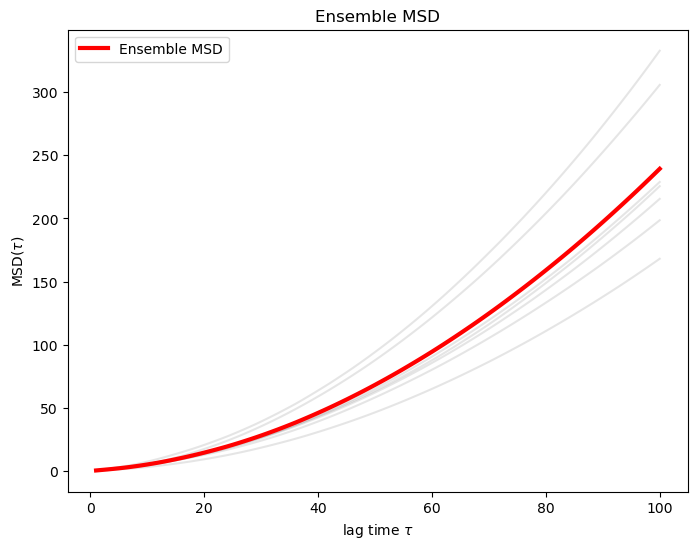


MSD exponent α = 1.5087311371822807
Superdiffusive / persistent behaviour


In [ ]:
import cv2
import numpy as np
import pandas as pd
import trackpy as tp
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ============================================================
# Load YOLO model
# ============================================================
model = YOLO("./weight/best.pt")

video_path = "./videos/for_2.3.mp4"

cap = cv2.VideoCapture(video_path)

all_points = []
frame_no = 0

# ============================================================
# YOLO + Local Refinement
# ============================================================
while True:
    ret, frame = cap.read()

    if not ret:
        break

    pred = model.predict(frame, verbose=False)

    boxes = pred[0].boxes.xyxy.cpu().numpy()

    for box in boxes:

        x1, y1, x2, y2 = box

        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        # ----------------------------------------------------
        # Padding around YOLO box
        # ----------------------------------------------------
        pad = 5

        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)

        x2p = min(frame.shape[1], x2 + pad)
        y2p = min(frame.shape[0], y2 + pad)

        roi = frame[y1p:y2p, x1p:x2p]

        if roi.size == 0:
            continue

        # ----------------------------------------------------
        # Grayscale
        # ----------------------------------------------------
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # ----------------------------------------------------
        # Local background subtraction
        # ----------------------------------------------------
        background = cv2.GaussianBlur(gray, (21, 21), 0)

        subtracted = cv2.subtract(background, gray)

        # ----------------------------------------------------
        # Threshold
        # ----------------------------------------------------
        _, binary = cv2.threshold(
            subtracted,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # ----------------------------------------------------
        # Moment refinement
        # ----------------------------------------------------
        M = cv2.moments(binary)

        if M["m00"] != 0:

            xc_roi = M["m10"] / M["m00"]
            yc_roi = M["m01"] / M["m00"]

            xc = x1p + xc_roi
            yc = y1p + yc_roi

        else:
            # fallback to YOLO center
            xc = (x1 + x2) / 2
            yc = (y1 + y2) / 2

        all_points.append({
            "frame": frame_no,
            "x": xc,
            "y": yc
        })

    frame_no += 1

cap.release()

print(f"Processed {frame_no} frames")

# ============================================================
# Create DataFrame
# ============================================================
df = pd.DataFrame(all_points)

print("\nFirst detections:")
print(df.head())

# ============================================================
# Detection statistics
# ============================================================
counts = df.groupby("frame").size()

print("\nDetection statistics:")
print(counts.describe())

plt.figure(figsize=(8, 4))
counts.plot()
plt.xlabel("Frame")
plt.ylabel("Number of detections")
plt.title("YOLO detections per frame")
plt.show()

# ============================================================
# Trackpy linking
# ============================================================
linked = tp.link(
    df,
    search_range=20,
    memory=5
)

print("\nFirst linked rows:")
print(linked.head())

# ============================================================
# Track lengths BEFORE filtering
# ============================================================

# ============================================================
# Keep only long trajectories
# ============================================================
track_lengths = linked.groupby("particle").size()

min_length = int(0.95 * frame_no)

good_ids = track_lengths[
    track_lengths >= min_length
].index

linked = linked[
    linked["particle"].isin(good_ids)
]

print("\nParticles kept:")
print(sorted(good_ids))

print("\nNumber of trajectories after filtering:",
      linked["particle"].nunique())
# ============================================================
# Overlay video with progressively growing trajectories
# ============================================================

video_path = "./videos/for_2.3.mp4"
output_path = "tracked_overlay.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

# ------------------------------------------------------------
# Assign a fixed color to each droplet
# ------------------------------------------------------------
particle_ids = sorted(linked["particle"].unique())

np.random.seed(42)

colors = {
    pid: tuple(int(c) for c in np.random.randint(50, 255, 3))
    for pid in particle_ids
}

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    current = linked[
        linked["frame"] == frame_idx
    ]

    for _, row in current.iterrows():

        pid = int(row["particle"])

        color = colors[pid]

        x = int(round(row["x"]))
        y = int(round(row["y"]))

        # ----------------------------------------------------
        # Entire trajectory from first appearance to now
        # ----------------------------------------------------
        history = linked[
            (linked["particle"] == pid) &
            (linked["frame"] <= frame_idx)
        ].sort_values("frame")

        pts = history[["x", "y"]].to_numpy()

        for i in range(1, len(pts)):

            p1 = tuple(
                np.int32(np.round(pts[i - 1]))
            )

            p2 = tuple(
                np.int32(np.round(pts[i]))
            )

            cv2.line(
                frame,
                p1,
                p2,
                color,
                2
            )

        # ----------------------------------------------------
        # Current droplet position
        # ----------------------------------------------------
        cv2.circle(
            frame,
            (x, y),
            6,
            color,
            -1
        )

        # ----------------------------------------------------
        # Particle ID
        # ----------------------------------------------------
        cv2.putText(
            frame,
            f"{pid}",
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
            cv2.LINE_AA
        )

    writer.write(frame)

    if frame_idx % 100 == 0:
        print(f"Writing frame {frame_idx}")

    frame_idx += 1

cap.release()
writer.release()

print("\nSaved overlay video:")
print(output_path)

print("\nTrack lengths:")
print(track_lengths.sort_values())

plt.figure(figsize=(7, 4))
track_lengths.hist(bins=30)
plt.xlabel("Track length (frames)")
plt.ylabel("Count")
plt.title("Track length distribution")
plt.show()

# ============================================================
# Keep only long trajectories
# ============================================================
min_length = int(0.8 * frame_no)

good_ids = track_lengths[
    track_lengths >= min_length
].index

linked = linked[
    linked["particle"].isin(good_ids)
]

print("\nParticles kept:")
print(sorted(good_ids))

print("\nNumber of trajectories after filtering:",
      linked["particle"].nunique())

# ============================================================
# Plot trajectories
# ============================================================
plt.figure(figsize=(8, 8))
tp.plot_traj(linked)
plt.title("Linked trajectories")
plt.show()

# ============================================================
# Individual MSD
# ============================================================
msd = tp.imsd(
    linked,
    mpp=1,
    fps=1
)

msd = msd.dropna(axis="columns")

print("\nMSD columns:")
print(msd.columns.tolist())

# ============================================================
# Plot MSDs
# ============================================================
plt.figure(figsize=(8, 6))

for col in msd.columns:

    plt.plot(
        msd.index,
        msd[col],
        alpha=0.4,
        lw=1,
        label=f"droplet-{col}"
    )

plt.xlabel(r'lag time $\tau$')
plt.ylabel(r'MSD($\tau$)')
plt.title("Individual MSDs")
plt.legend()
plt.show()

# ============================================================
# Ensemble MSD
# ============================================================
ensemble_msd = msd.mean(axis=1)

plt.figure(figsize=(8, 6))

for col in msd.columns:
    plt.plot(
        msd.index,
        msd[col],
        alpha=0.2,
        color='gray'
    )

plt.plot(
    ensemble_msd.index,
    ensemble_msd.values,
    color='red',
    linewidth=3,
    label='Ensemble MSD'
)

plt.xlabel(r'lag time $\tau$')
plt.ylabel(r'MSD($\tau$)')
plt.title("Ensemble MSD")
plt.legend()
plt.show()

# ============================================================
# Optional: MSD scaling exponent
# ============================================================
log_tau = np.log10(ensemble_msd.index.values)
log_msd = np.log10(ensemble_msd.values)

slope, intercept = np.polyfit(log_tau, log_msd, 1)

print("\nMSD exponent α =", slope)

if slope < 0.9:
    print("Subdiffusive behaviour")
elif slope < 1.1:
    print("Approximately diffusive behaviour")
else:
    print("Superdiffusive / persistent behaviour")


In [54]:
video_path = "./videos/for_2.3.mp4"

import os 
for i in os.listdir('./videos'):
    
    u = i.split('/')[-1].split('.mp4')[0]
    print(u)
    

for_2&4ul
for_2.1
for_2.2
for_2.3
for_2.4


In [ ]:
def all_videos(video_path):
    # ============================================================
    # Load YOLO model
    # ============================================================
    model = YOLO("./weight/best.pt")

    # video_path = "./videos/for_2.3.mp4"

    cap = cv2.VideoCapture(video_path)

    all_points = []
    frame_no = 0

    # ============================================================
    # YOLO + Local Refinement
    # ============================================================
    while True:
        ret, frame = cap.read()

        if not ret:
            break

        pred = model.predict(frame, verbose=False)

        boxes = pred[0].boxes.xyxy.cpu().numpy()

        for box in boxes:

            x1, y1, x2, y2 = box

            x1 = int(x1)
            y1 = int(y1)
            x2 = int(x2)
            y2 = int(y2)

            # ----------------------------------------------------
            # Padding around YOLO box
            # ----------------------------------------------------
            pad = 5

            x1p = max(0, x1 - pad)
            y1p = max(0, y1 - pad)

            x2p = min(frame.shape[1], x2 + pad)
            y2p = min(frame.shape[0], y2 + pad)

            roi = frame[y1p:y2p, x1p:x2p]

            if roi.size == 0:
                continue

            # ----------------------------------------------------
            # Grayscale
            # ----------------------------------------------------
            gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

            # ----------------------------------------------------
            # Local background subtraction
            # ----------------------------------------------------
            background = cv2.GaussianBlur(gray, (21, 21), 0)

            subtracted = cv2.subtract(background, gray)

            # ----------------------------------------------------
            # Threshold
            # ----------------------------------------------------
            _, binary = cv2.threshold(
                subtracted,
                0,
                255,
                cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )

            # ----------------------------------------------------
            # Moment refinement
            # ----------------------------------------------------
            M = cv2.moments(binary)

            if M["m00"] != 0:

                xc_roi = M["m10"] / M["m00"]
                yc_roi = M["m01"] / M["m00"]

                xc = x1p + xc_roi
                yc = y1p + yc_roi

            else:
                # fallback to YOLO center
                xc = (x1 + x2) / 2
                yc = (y1 + y2) / 2

            all_points.append({
                "frame": frame_no,
                "x": xc,
                "y": yc
            })

        frame_no += 1

    cap.release()

    print(f"Processed {frame_no} frames")

    # ============================================================
    # Create DataFrame
    # ============================================================
    df = pd.DataFrame(all_points)

    print("\nFirst detections:")
    print(df.head())

    # ============================================================
    # Detection statistics
    # ============================================================
    counts = df.groupby("frame").size()

    print("\nDetection statistics:")
    print(counts.describe())

    plt.figure(figsize=(8, 4))
    counts.plot()
    plt.xlabel("Frame")
    plt.ylabel("Number of detections")
    plt.title("YOLO detections per frame")
    plt.show()

    # ============================================================
    # Trackpy linking
    # ============================================================
    linked = tp.link(
        df,
        search_range=20,
        memory=5
    )

    print("\nFirst linked rows:")
    print(linked.head())

    # ============================================================
    # Track lengths BEFORE filtering
    # ============================================================

    # ============================================================
    # Keep only long trajectories
    # ============================================================
    track_lengths = linked.groupby("particle").size()

    min_length = int(0.95 * frame_no)

    good_ids = track_lengths[
        track_lengths >= min_length
    ].index

    linked = linked[
        linked["particle"].isin(good_ids)
    ]

    print("\nParticles kept:")
    print(sorted(good_ids))

    print("\nNumber of trajectories after filtering:",
        linked["particle"].nunique())
    # ============================================================
    # Overlay video with progressively growing trajectories
    # ============================================================

    name = f"trajectory_{video_path.split('/')[-1].split('.mp4')[0]}.mp4"
    output_path = os.path.join('./videos',name)

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    writer = cv2.VideoWriter(
        output_path,
        fourcc,
        fps,
        (width, height)
    )

    # ------------------------------------------------------------
    # Assign a fixed color to each droplet
    # ------------------------------------------------------------
    particle_ids = sorted(linked["particle"].unique())

    np.random.seed(42)

    colors = {
        pid: tuple(int(c) for c in np.random.randint(50, 255, 3))
        for pid in particle_ids
    }

    frame_idx = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        current = linked[
            linked["frame"] == frame_idx
        ]

        for _, row in current.iterrows():

            pid = int(row["particle"])

            color = colors[pid]

            x = int(round(row["x"]))
            y = int(round(row["y"]))

            # ----------------------------------------------------
            # Entire trajectory from first appearance to now
            # ----------------------------------------------------
            history = linked[
                (linked["particle"] == pid) &
                (linked["frame"] <= frame_idx)
            ].sort_values("frame")

            pts = history[["x", "y"]].to_numpy()

            for i in range(1, len(pts)):

                p1 = tuple(
                    np.int32(np.round(pts[i - 1]))
                )

                p2 = tuple(
                    np.int32(np.round(pts[i]))
                )

                cv2.line(
                    frame,
                    p1,
                    p2,
                    color,
                    2
                )

            # ----------------------------------------------------
            # Current droplet position
            # ----------------------------------------------------
            cv2.circle(
                frame,
                (x, y),
                6,
                color,
                -1
            )

            # ----------------------------------------------------
            # Particle ID
            # ----------------------------------------------------
            cv2.putText(
                frame,
                f"{pid}",
                (x + 8, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2,
                cv2.LINE_AA
            )

        writer.write(frame)

        if frame_idx % 100 == 0:
            print(f"Writing frame {frame_idx}")

        frame_idx += 1

    cap.release()
    writer.release()

    print("\nSaved overlay video:")
    print(output_path)

    print("\nTrack lengths:")
    print(track_lengths.sort_values())

    plt.figure(figsize=(7, 4))
    track_lengths.hist(bins=30)
    plt.xlabel("Track length (frames)")
    plt.ylabel("Count")
    plt.title("Track length distribution")
    plt.show()

    # ============================================================
    # Keep only long trajectories
    # ============================================================
    min_length = int(0.8 * frame_no)

    good_ids = track_lengths[
        track_lengths >= min_length
    ].index

    linked = linked[
        linked["particle"].isin(good_ids)
    ]

    print("\nParticles kept:")
    print(sorted(good_ids))

    print("\nNumber of trajectories after filtering:",
        linked["particle"].nunique())

    # ============================================================
    # Plot trajectories
    # ============================================================
    plt.figure(figsize=(8, 8))
    tp.plot_traj(linked)
    plt.title("Linked trajectories")
    plt.show()

    # ============================================================
    # Individual MSD
    # ============================================================
    msd = tp.imsd(
        linked,
        mpp=1,
        fps=1
    )

    msd = msd.dropna(axis="columns")

    print("\nMSD columns:")
    print(msd.columns.tolist())

    # ============================================================
    # Plot MSDs
    # ============================================================
    plt.figure(figsize=(8, 6))

    for col in msd.columns:

        plt.plot(
            msd.index,
            msd[col],
            alpha=0.4,
            lw=1,
            label=f"droplet-{col}"
        )

    plt.xlabel(r'lag time $\tau$')
    plt.ylabel(r'MSD($\tau$)')
    plt.title("Individual MSDs")
    plt.legend()
    plt.show()

    # ============================================================
    # Ensemble MSD
    # ============================================================
    ensemble_msd = msd.mean(axis=1)

    plt.figure(figsize=(8, 6))

    for col in msd.columns:
        plt.plot(
            msd.index,
            msd[col],
            alpha=0.2,
            color='gray'
        )

    plt.plot(
        ensemble_msd.index,
        ensemble_msd.values,
        color='red',
        linewidth=3,
        label='Ensemble MSD'
    )

    plt.xlabel(r'lag time $\tau$')
    plt.ylabel(r'MSD($\tau$)')
    plt.title("Ensemble MSD")
    plt.legend()
    plt.show()

    # ============================================================
    # Optional: MSD scaling exponent
    # ============================================================
    log_tau = np.log10(ensemble_msd.index.values)
    log_msd = np.log10(ensemble_msd.values)

    slope, intercept = np.polyfit(log_tau, log_msd, 1)

    print("\nMSD exponent α =", slope)

    if slope < 0.9:
        print("Subdiffusive behaviour")
    elif slope < 1.1:
        print("Approximately diffusive behaviour")
    else:
        print("Superdiffusive / persistent behaviour")


In [59]:


import os 
for i in os.listdir('./videos'):
    path = os.path.join('./videos',i)
    all_videos(path)
    
   

Frame 3950: 7 trajectories present.

First linked rows:
   frame           x           y  particle
0      0  293.712500  117.302500         0
1      0  404.492537  261.289552         1
2      0   58.269231  139.214286         2
3      0  375.564356  122.710396         3
4      0  335.769231  426.205128         4

Particles kept:
[0, 1, 3, 4, 5, 6, 7]

Number of trajectories after filtering: 7
Writing frame 0
Writing frame 100
Writing frame 200
Writing frame 300
Writing frame 400
Writing frame 500
Writing frame 600
Writing frame 700


KeyboardInterrupt: 

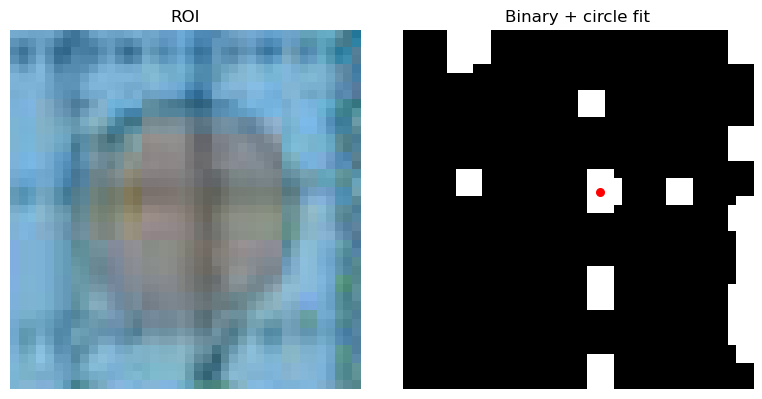

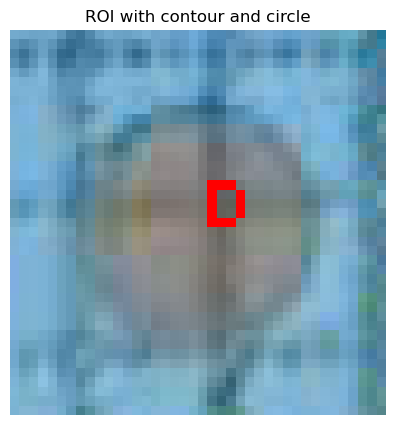

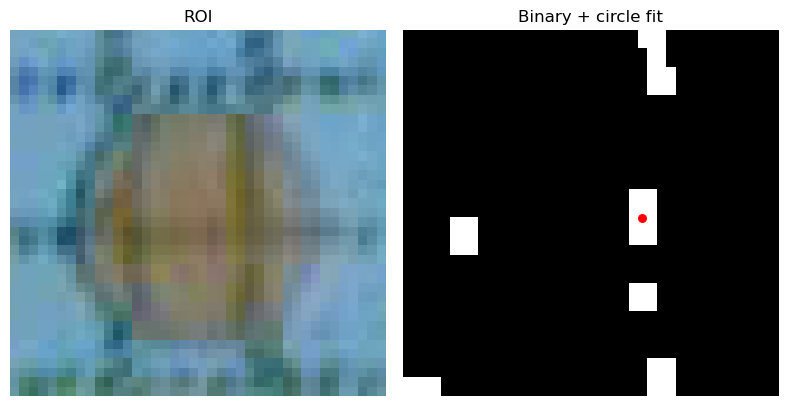

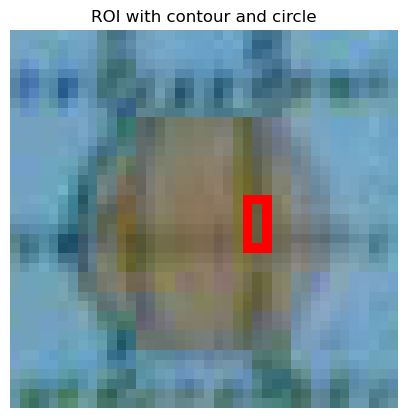

Processed 3951 frames

First few rows:
   frame      x      y  radius  confidence  yolo_x1  yolo_y1  yolo_x2  yolo_y2
0      0  293.5  117.5     NaN    0.893067      277      100      310      135
1      0  404.0  260.0     NaN    0.887925      388      244      420      276
2      0   59.0  139.0     NaN    0.878689       44      124       74      154
3      0  373.0  124.5     NaN    0.864945      358      109      388      140
4      0  341.5  429.0     NaN    0.859395      327      414      356      444

Saved CSV to: yolo_circle_localization.csv

Detection statistics:
count    3951.000000
mean        7.622627
std         0.567548
min         6.000000
25%         7.000000
50%         8.000000
75%         8.000000
max        11.000000
dtype: float64


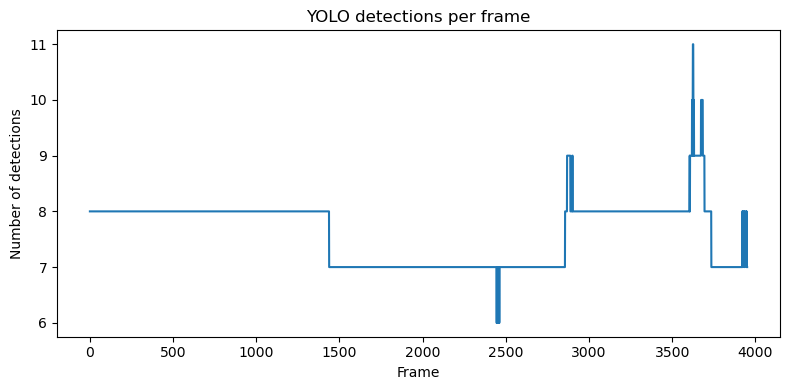

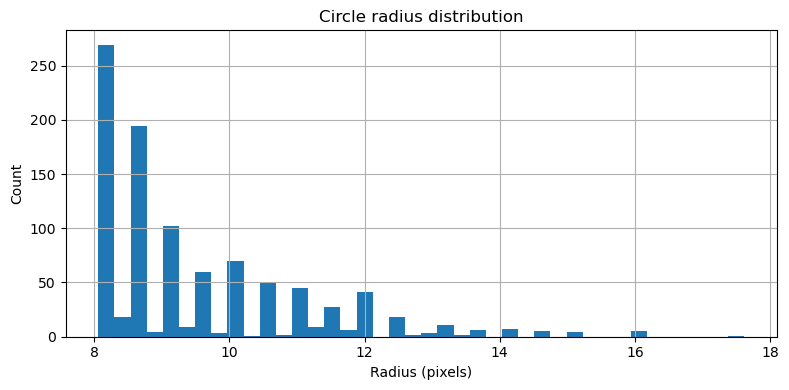

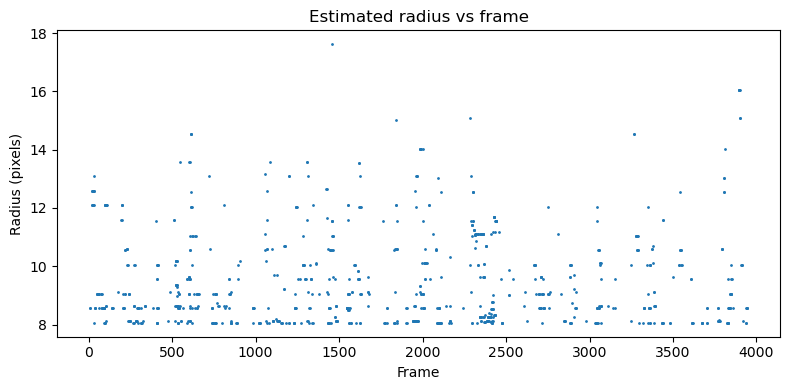

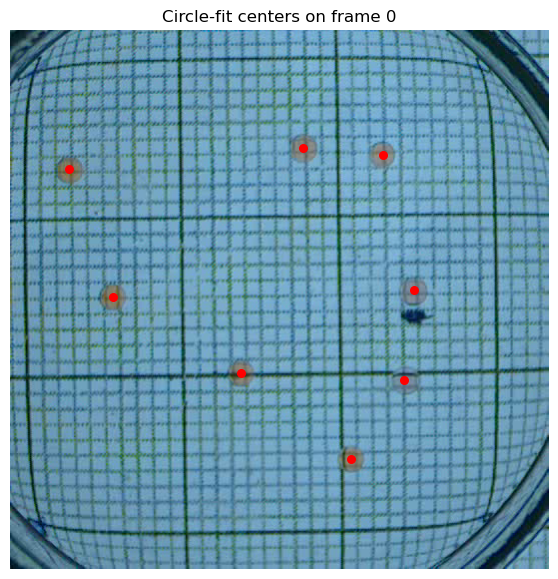

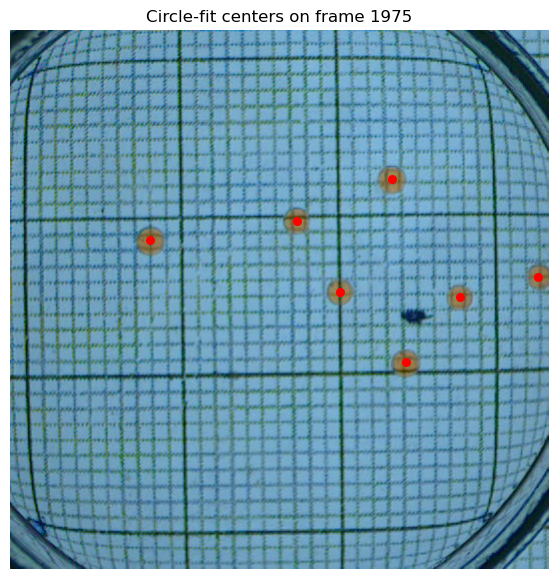

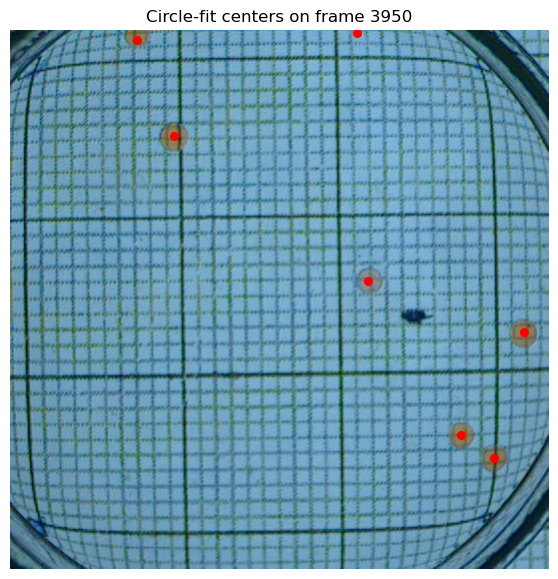

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ============================================================
# YOLO + Circle Fit Localization
# ------------------------------------------------------------
# Output:
#   1) CSV with columns: frame, x, y, radius, confidence, particle_like_id
#   2) Basic diagnostic plots
# ============================================================

# ----------------------------
# User settings
# ----------------------------
model_path = "./weight/best.pt"
video_path = "./videos/for_2.3.mp4"
output_csv = "yolo_circle_localization.csv"

# Optional preprocessing / fitting parameters
pad = 5                 # padding around YOLO box
blur_ksize = (21, 21)   # background subtraction blur kernel
min_contour_area = 10    # ignore tiny contours
save_debug_plots = True  # set False if you only want CSV
debug_frame_to_show = 0  # pick a frame index for ROI debugging

# ----------------------------
# Load YOLO model
# ----------------------------
model = YOLO(model_path)

# ----------------------------
# Open video
# ----------------------------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

frame_no = 0
all_points = []

# ============================================================
# Main loop: detect -> crop ROI -> threshold -> circle fit
# ============================================================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # YOLO prediction on this frame
    pred = model.predict(frame, verbose=False)
    boxes = pred[0].boxes.xyxy.cpu().numpy()

    # Optional confidences, if available
    confs = None
    if pred[0].boxes.conf is not None:
        confs = pred[0].boxes.conf.cpu().numpy()

    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = box

        # Convert YOLO box to integers
        x1 = int(x1)
        y1 = int(y1)
        x2 = int(x2)
        y2 = int(y2)

        # Confidence for this detection, if present
        conf = float(confs[idx]) if confs is not None and idx < len(confs) else np.nan

        # ----------------------------------------------------
        # Add padding around YOLO box
        # ----------------------------------------------------
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(frame.shape[1], x2 + pad)
        y2p = min(frame.shape[0], y2 + pad)

        roi = frame[y1p:y2p, x1p:x2p]
        if roi.size == 0:
            continue

        # ----------------------------------------------------
        # Convert ROI to grayscale
        # ----------------------------------------------------
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

        # ----------------------------------------------------
        # Local background subtraction
        # The droplets are darker than background, so:
        # background - gray makes droplets bright
        # ----------------------------------------------------
        background = cv2.GaussianBlur(gray, blur_ksize, 0)
        subtracted = cv2.subtract(background, gray)

        # ----------------------------------------------------
        # Threshold to binary
        # ----------------------------------------------------
        _, binary = cv2.threshold(
            subtracted,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # ----------------------------------------------------
        # Clean up binary mask a little
        # ----------------------------------------------------
        kernel = np.ones((3, 3), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

        # ----------------------------------------------------
        # Find contours
        # ----------------------------------------------------
        contours, _ = cv2.findContours(
            binary,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE
        )

        if len(contours) == 0:
            # Fallback to YOLO center if contour extraction fails
            xc = (x1 + x2) / 2.0
            yc = (y1 + y2) / 2.0
            radius = np.nan

            all_points.append({
                "frame": frame_no,
                "x": xc,
                "y": yc,
                "radius": radius,
                "confidence": conf,
                "yolo_x1": x1,
                "yolo_y1": y1,
                "yolo_x2": x2,
                "yolo_y2": y2
            })
            continue

        # Pick the largest contour
        # largest_contour = max(contours, key=cv2.contourArea)
        
        # Expected droplet center inside ROI
        cx0 = (x1 + x2)/2 - x1p
        cy0 = (y1 + y2)/2 - y1p
        # cx0 = binary.shape[1] / 2
        # cy0 = binary.shape[0] / 2

        best_contour = None
        best_dist = np.inf

        for cnt in contours:

            area = cv2.contourArea(cnt)

            if area < min_contour_area:
                continue
            touches_edge = np.any(
                    (cnt[:, 0, 0] <= 1) |
                    (cnt[:, 0, 1] <= 1) |
                    (cnt[:, 0, 0] >= binary.shape[1] - 2) |
                    (cnt[:, 0, 1] >= binary.shape[0] - 2)
                )
            if touches_edge:
                continue

            M = cv2.moments(cnt)

            if M["m00"] == 0:
                continue

            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]

            dist = np.sqrt((cx-cx0)**2 + (cy-cy0)**2)

            if dist < best_dist:
                best_dist = dist
                best_contour = cnt
        
        if best_contour is None:
            xc = (x1 + x2) / 2
            yc = (y1 + y2) / 2
            radius = np.nan

            all_points.append({
                "frame": frame_no,
                "x": xc,
                "y": yc,
                "radius": radius,
                "confidence": conf,
                "yolo_x1": x1,
                "yolo_y1": y1,
                "yolo_x2": x2,
                "yolo_y2": y2
            })
            continue
        
        contour = best_contour
        
        area = cv2.contourArea(contour)
        
        if area < min_contour_area:
            # Fallback to YOLO center if contour is too small
            xc = (x1 + x2) / 2.0
            yc = (y1 + y2) / 2.0
            radius = np.nan

            all_points.append({
                "frame": frame_no,
                "x": xc,
                "y": yc,
                "radius": radius,
                "confidence": conf,
                "yolo_x1": x1,
                "yolo_y1": y1,
                "yolo_x2": x2,
                "yolo_y2": y2
            })
            continue

        # ----------------------------------------------------
        # Circle fit using minEnclosingCircle
        # ----------------------------------------------------
       # Circle fit
        (xc_roi, yc_roi), radius_fit = cv2.minEnclosingCircle(contour)

        # Save raw values for debugging
        debug_radius = radius_fit
        debug_xc = xc_roi
        debug_yc = yc_roi

        # Radius sanity check
        if radius_fit < 8 or radius_fit > 20:
            # Fallback to YOLO center
            xc = (x1 + x2) / 2
            yc = (y1 + y2) / 2
            radius = np.nan

        else:
            # Accept circle fit
            xc = x1p + xc_roi
            yc = y1p + yc_roi
            radius = radius_fit

        # Save result
        all_points.append({
            "frame": frame_no,
            "x": xc,
            "y": yc,
            "radius": radius,
            "confidence": conf,
            "yolo_x1": x1,
            "yolo_y1": y1,
            "yolo_x2": x2,
            "yolo_y2": y2
        })

        # ----------------------------------------------------
        # Optional debug visualizations for one chosen frame
        # ----------------------------------------------------
        if save_debug_plots and frame_no == debug_frame_to_show:
            roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

            # Draw contour and circle on a copy of the ROI
            roi_vis = roi_rgb.copy()
            cv2.drawContours(roi_vis, [contour], -1, (255, 0, 0), 1)
            if not np.isnan(radius):
                cv2.circle(
                    roi_vis,
                    (int(round(xc_roi)), int(round(yc_roi))),
                    int(round(radius)),
                    (0, 255, 0),
                    1
                )
                cv2.circle(
                    roi_vis,
                    (int(round(xc_roi)), int(round(yc_roi))),
                    3,
                    (255, 0, 0),
                    -1
                )

            plt.figure(figsize=(8, 4))

            plt.subplot(1, 2, 1)
            plt.title("ROI")
            plt.imshow(roi_rgb)
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.title("Binary + circle fit")
            plt.imshow(binary, cmap="gray")
            plt.scatter([xc_roi], [yc_roi], c="r", s=30)
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(5, 5))
            plt.title("ROI with contour and circle")
            plt.imshow(roi_vis)
            plt.axis("off")
            plt.show()

    frame_no += 1

cap.release()

print(f"Processed {frame_no} frames")

# ============================================================
# Create DataFrame and save CSV
# ============================================================
df = pd.DataFrame(all_points)

print("\nFirst few rows:")
print(df.head())

df.to_csv(output_csv, index=False)
print(f"\nSaved CSV to: {output_csv}")

# ============================================================
# Basic diagnostics
# ============================================================
counts = df.groupby("frame").size()

print("\nDetection statistics:")
print(counts.describe())

plt.figure(figsize=(8, 4))
counts.plot()
plt.xlabel("Frame")
plt.ylabel("Number of detections")
plt.title("YOLO detections per frame")
plt.tight_layout()
plt.show()

# Radius distribution
plt.figure(figsize=(8, 4))
df["radius"].dropna().hist(bins=40)
plt.xlabel("Radius (pixels)")
plt.ylabel("Count")
plt.title("Circle radius distribution")
plt.tight_layout()
plt.show()

# Radius vs frame
plt.figure(figsize=(8, 4))
plt.plot(df["frame"], df["radius"], ".", ms=2)
plt.xlabel("Frame")
plt.ylabel("Radius (pixels)")
plt.title("Estimated radius vs frame")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: overlay circle centers on a few sample frames
# ============================================================
sample_frames = [0, frame_no // 2, frame_no - 1]
sample_frames = [f for f in sample_frames if f >= 0]

cap = cv2.VideoCapture(video_path)

for sf in sample_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, sf)
    ret, frame = cap.read()
    if not ret:
        continue

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_df = df[df["frame"] == sf]

    plt.figure(figsize=(7, 7))
    plt.imshow(frame_rgb)
    plt.scatter(frame_df["x"], frame_df["y"], c="r", s=30)
    plt.title(f"Circle-fit centers on frame {sf}")
    plt.axis("off")
    plt.show()

cap.release()


In [ ]:
mom = pd.read_csv("moments_localization.csv")
cir = pd.read_csv("yolo_circle_localization.csv")

mom["det"] = mom.groupby("frame").cumcount()
cir["det"] = cir.groupby("frame").cumcount()

mom_counts = mom.groupby("frame").size()
cir_counts = cir.groupby("frame").size()

print((mom_counts == cir_counts).all())


True


In [ ]:
merged = mom.merge(
    cir,
    on=["frame", "det"],
    suffixes=("_mom", "_cir")
)

merged["delta"] = np.sqrt(
    (merged["x_cir"] - merged["x_mom"])**2 +
    (merged["y_cir"] - merged["y_mom"])**2
)


In [ ]:
print(mom.columns)
print(cir.columns)

mom_counts = mom.groupby("frame").size()
cir_counts = cir.groupby("frame").size()

print("All counts equal?",
      (mom_counts == cir_counts).all())

print("Frames with unequal counts:",
      np.sum(mom_counts != cir_counts))


Index(['frame', 'x', 'y', 'radius', 'confidence', 'yolo_x1', 'yolo_y1',
       'yolo_x2', 'yolo_y2', 'det'],
      dtype='object')
Index(['frame', 'x', 'y', 'radius', 'confidence', 'yolo_x1', 'yolo_y1',
       'yolo_x2', 'yolo_y2', 'det'],
      dtype='object')
All counts equal? True
Frames with unequal counts: 0


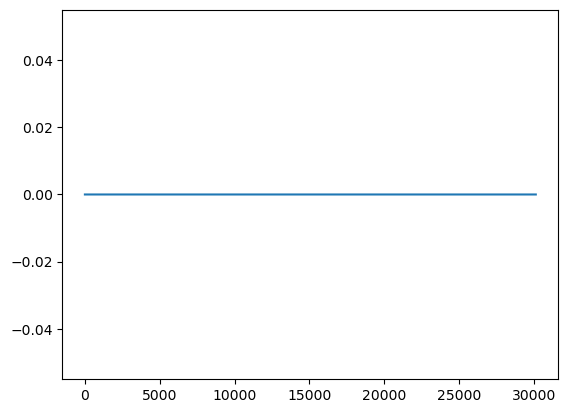

In [11]:
plt.plot(np.arange(0,merged['delta'].values.shape[0],1),merged['delta'].values)


count    30117.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: delta, dtype: float64
Median = 0.0
Mean = 0.0
Max = 0.0


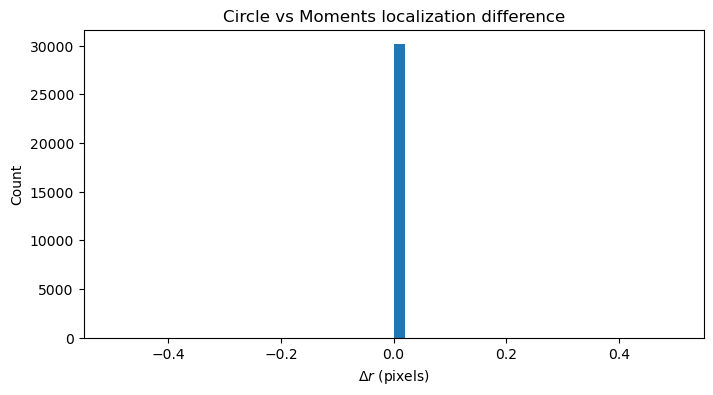

In [ ]:
print(merged["delta"].describe())

print("Median =", merged["delta"].median())
print("Mean =", merged["delta"].mean())
print("Max =", merged["delta"].max())

plt.figure(figsize=(8,4))
plt.hist(merged["delta"], bins=50)
plt.xlabel(r'$\Delta r$ (pixels)')
plt.ylabel("Count")
plt.title("Circle vs Moments localization difference")
plt.show()


In [ ]:
print(mom.head())
print()
print(cir.head())


   frame      x      y  radius  confidence  yolo_x1  yolo_y1  yolo_x2  \
0      0  293.5  117.5     NaN    0.893067      277      100      310   
1      0  404.0  260.0     NaN    0.887925      388      244      420   
2      0   59.0  139.0     NaN    0.878689       44      124       74   
3      0  373.0  124.5     NaN    0.864945      358      109      388   
4      0  341.5  429.0     NaN    0.859395      327      414      356   

   yolo_y2  det  
0      135    0  
1      276    1  
2      154    2  
3      140    3  
4      444    4  

   frame      x      y  radius  confidence  yolo_x1  yolo_y1  yolo_x2  \
0      0  293.5  117.5     NaN    0.893067      277      100      310   
1      0  404.0  260.0     NaN    0.887925      388      244      420   
2      0   59.0  139.0     NaN    0.878689       44      124       74   
3      0  373.0  124.5     NaN    0.864945      358      109      388   
4      0  341.5  429.0     NaN    0.859395      327      414      356   

   yolo_y2  d

In [ ]:
print((mom == cir).all())


frame          True
x              True
y              True
radius        False
confidence     True
yolo_x1        True
yolo_y1        True
yolo_x2        True
yolo_y2        True
det            True
dtype: bool


In [ ]:
image_path = './test_images/0003305.png'
image_path2 = './test_images/0002162.png'

video_path ='./videos/for_2.2.mp4'


# trackers = ['botsort.yaml',
# 'bytetrack.yaml',
# 'ocsort.yaml',
# 'deepocsort.yaml',
# 'fasttrack.yaml',
# 'tracktrack.yaml']


trackers = ['botsort.yaml',
'bytetrack.yaml']

model = YOLO('./weight/best.pt')
for tracker in trackers:
    results = model.track(source=video_path, tracker=tracker,)
    print(results[0].boxes.xyxy.cpu().numpy())



image 1/1 /mnt/g/Work/PROJECT-ALL/combine - Copy/test_images/0003305.png: 768x768 5 droplets, 9.7ms
Speed: 2.8ms preprocess, 9.7ms inference, 2.0ms postprocess per image at shape (1, 3, 768, 768)
[[     285.96      406.62      321.14      441.79]
 [     95.031           0       132.8      23.385]
 [     104.77      354.66      142.34      392.96]
 [     279.03      154.95      315.07      191.25]
 [     92.155      398.34       129.3      434.14]]

image 1/1 /mnt/g/Work/PROJECT-ALL/combine - Copy/test_images/0003305.png: 768x768 5 droplets, 9.7ms
Speed: 3.1ms preprocess, 9.7ms inference, 1.8ms postprocess per image at shape (1, 3, 768, 768)
[[     285.96      406.62      321.14      441.79]
 [     95.031           0       132.8      23.385]
 [     104.77      354.66      142.34      392.96]
 [     279.03      154.95      315.07      191.25]
 [     92.155      398.34       129.3      434.14]]


In [ ]:
# Method 1: Bounding-box center
# Method 2: Contour centroid
# Method 3: Intensity-weighted centroid


In [ ]:
from abc import ABC,abstractmethod

class BaseTracker(ABC):
    @abstractmethod
    def compute_center(self):
        pass
    
class Bounding(BaseTracker):
    def compute_center(self):
        pass
    
    
class ContourCentroid(BaseTracker):
    def compute_center(self):
        pass
    
class WeightedCentroid(BaseTracker):
    def compute_center(self):
        pass


In [ ]:
from PIL import Image
im = Image.open(image_path2).convert("L")
frame = np.array(im)


In [ ]:
frame.shape


(540, 540)

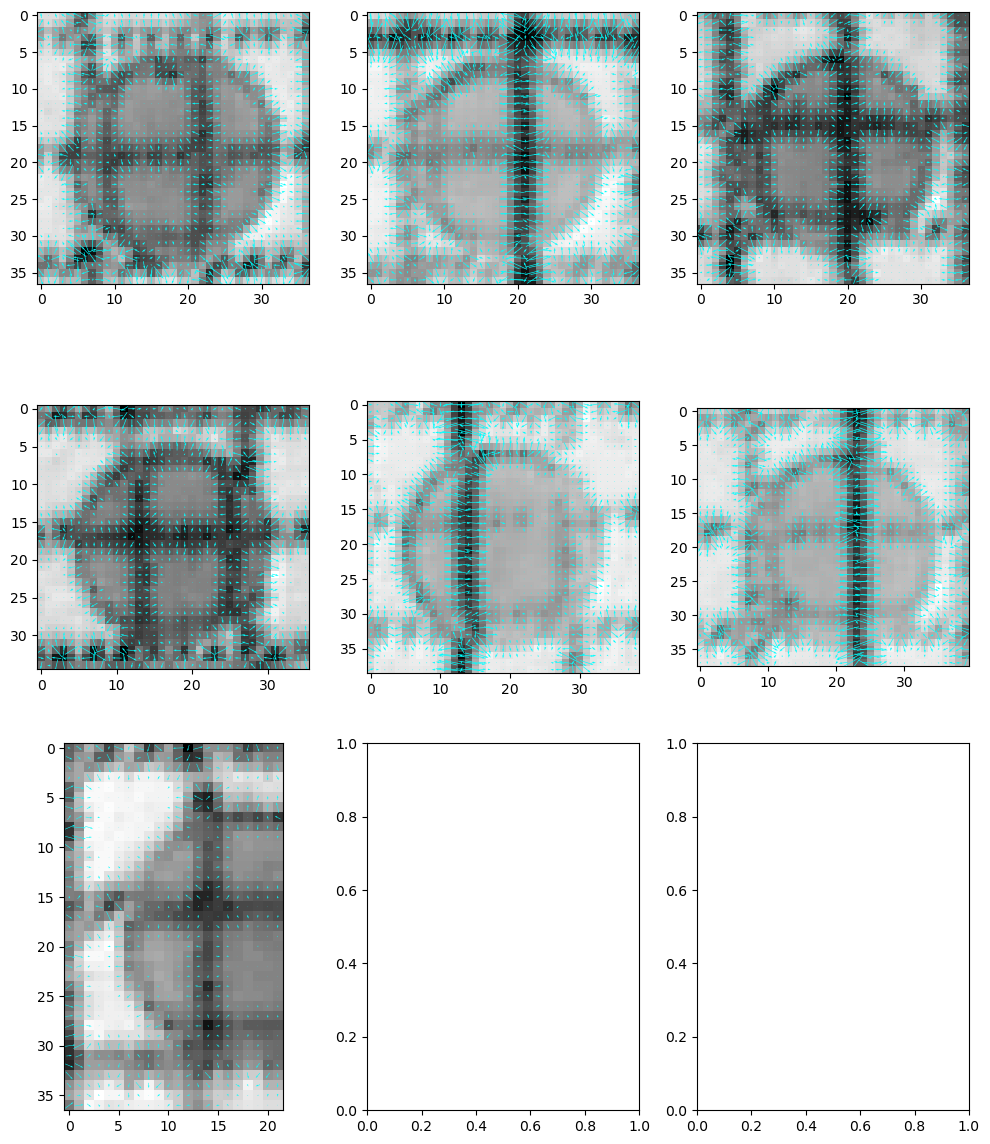

In [ ]:

from PIL import Image
im = Image.open(image_path2).convert("L")
frame = np.array(im)
pred = model.predict(image_path2, verbose=False)

boxes = pred[0].boxes.xyxy.cpu().numpy()


fig,ax = plt.subplots(3,3)
ax = ax.flatten()



for idx,box in enumerate(boxes):

    x1, y1, x2, y2 = box
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    # ----------------------------------------------------
    # Padding around YOLO box
    # ----------------------------------------------------
    pad = 3

    x1p = max(0, x1 - pad)
    y1p = max(0, y1 - pad)

    x2p = min(frame.shape[1], x2 + pad)
    y2p = min(frame.shape[0], y2 + pad)

    roi = frame[y1p:y2p, x1p:x2p]
    # gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    
    # background = cv2.GaussianBlur(gray, (21, 21), 0)

    # subtracted = cv2.subtract(background, gray)
    gy,gx = np.gradient(roi)
    
    
    h, w = roi.shape
    Y, X = np.mgrid[0:h, 0:w]

    # 3. Subsample the data (take every 15th pixel) so the plot isn't crowded
    step = 1
    X_sub = X[::step, ::step]
    Y_sub = Y[::step, ::step]
    gx_sub = gx[::step, ::step]
    gy_sub = gy[::step, ::step]

    # 4. Plot the vector field over the grayscale image
    # ax[idx].figure(figsize=(10, 8))
    ax[idx].imshow(roi, cmap='gray', origin='upper')

    # Quiver plots vectors. Note: -gy is often used because image Y-axis points down
    ax[idx].quiver(X_sub, Y_sub, gx_sub, -gy_sub, color='cyan', scale=500, pivot='mid')
    
    
    # ax[idx].imshow(roi)
    
fig.set_size_inches(10,12)
plt.tight_layout()


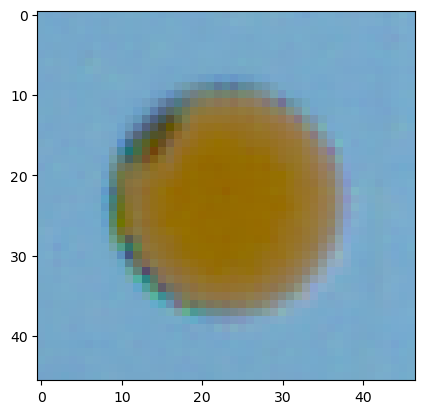

In [ ]:
plt.imshow(roi)


In [ ]:
roi.shape


(42, 43, 3)

In [ ]:
im.size


(540, 540)

In [ ]:
import numpy as np
from scipy.optimize import least_squares


def radial_circle_fit(roi,
                      center0=None,
                      n_angles=180,
                      radial_tol=4):
    """
    Parameters
    ----------
    roi : 2D ndarray
        Grayscale droplet ROI.

    center0 : tuple (xc0, yc0)
        Initial center estimate.
        If None, use ROI center.

    n_angles : int
        Number of angular bins.

    radial_tol : float
        Width of annulus around expected radius.

    Returns
    -------
    xc, yc : float
        Estimated center (ROI coordinates).

    R : float
        Estimated radius.

    boundary_pts : ndarray
        Nx2 array of boundary points used in fit.
    """

    roi = roi.astype(float)

    h, w = roi.shape

    if center0 is None:
        xc0 = w / 2
        yc0 = h / 2
    else:
        xc0, yc0 = center0

    # --------------------------------------------------
    # Expected radius from ROI size
    # --------------------------------------------------
    R0 = min(h, w) / 2 - 2

    # --------------------------------------------------
    # Gradients
    # --------------------------------------------------
    gy, gx = np.gradient(roi)

    mag = np.sqrt(gx**2 + gy**2)

    # --------------------------------------------------
    # Pixel coordinates
    # --------------------------------------------------
    Y, X = np.mgrid[0:h, 0:w]

    dx = X - xc0
    dy = Y - yc0

    r = np.sqrt(dx**2 + dy**2)

    theta = np.arctan2(dy, dx)
    theta = (theta + 2*np.pi) % (2*np.pi)

    # --------------------------------------------------
    # Restrict to annulus near expected radius
    # --------------------------------------------------
    mask = (
        (r > R0 - radial_tol) &
        (r < R0 + radial_tol)
    )

    Xm = X[mask]
    Ym = Y[mask]
    Mm = mag[mask]
    Tm = theta[mask]

    # --------------------------------------------------
    # One strongest gradient per angle
    # --------------------------------------------------
    bins = np.linspace(0, 2*np.pi, n_angles + 1)

    boundary_pts = []

    for i in range(n_angles):

        sel = (
            (Tm >= bins[i]) &
            (Tm < bins[i+1])
        )

        if np.any(sel):

            idx = np.argmax(Mm[sel])

            xs = Xm[sel]
            ys = Ym[sel]

            boundary_pts.append(
                (xs[idx], ys[idx])
            )

    boundary_pts = np.array(boundary_pts)

    # --------------------------------------------------
    # Circle fit
    # --------------------------------------------------
    def residuals(params):

        xc, yc, R = params

        d = np.sqrt(
            (boundary_pts[:, 0] - xc)**2 +
            (boundary_pts[:, 1] - yc)**2
        )

        return d - R

    x0 = [xc0, yc0, R0]

    result = least_squares(residuals, x0)

    xc, yc, R = result.x

    return xc, yc, R, boundary_pts


18.74298086826969 18.837113177428527 16.314417000280958


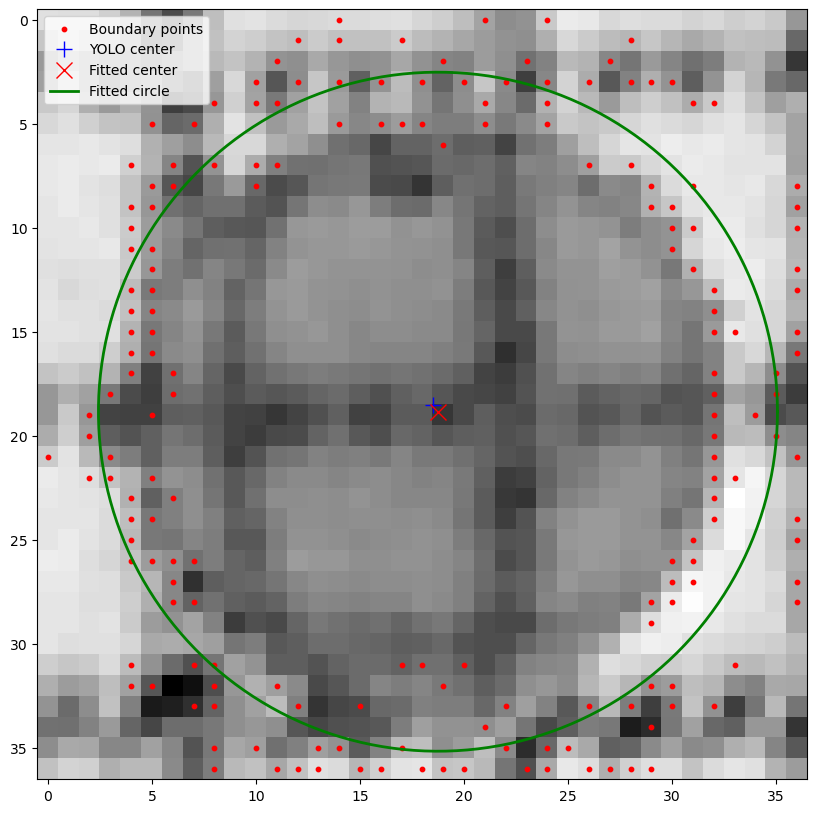

In [ ]:

from PIL import Image
im = Image.open(image_path2).convert("L")
frame = np.array(im)
pred = model.predict(image_path2, verbose=False)

boxes = pred[0].boxes.xyxy.cpu().numpy()


fig,ax = plt.subplots(1)
# ax = ax.flatten()



for idx,box in enumerate(boxes):

    x1, y1, x2, y2 = box
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    # ----------------------------------------------------
    # Padding around YOLO box
    # ----------------------------------------------------
    pad = 3

    x1p = max(0, x1 - pad)
    y1p = max(0, y1 - pad)

    x2p = min(frame.shape[1], x2 + pad)
    y2p = min(frame.shape[0], y2 + pad)

    roi = frame[y1p:y2p, x1p:x2p]

    h, w = roi.shape

    xc0 = w / 2
    yc0 = h / 2

    xc, yc, R, pts = radial_circle_fit(
        roi,
        center0=(xc0, yc0),
        n_angles=180,
        radial_tol=4
    )
    ax.imshow(roi, cmap='gray')

    # Selected boundary points
    ax.scatter(
        pts[:,0],
        pts[:,1],
        s=10,
        c='red',
        label='Boundary points'
    )

    # YOLO center
    ax.plot(
        xc0,
        yc0,
        'b+',
        markersize=12,
        label='YOLO center'
    )

    # Refined center
    ax.plot(
        xc,
        yc,
        'rx',
        markersize=12,
        label='Fitted center'
    )

    # Fitted circle
    theta = np.linspace(0, 2*np.pi, 200)

    ax.plot(
        xc + R*np.cos(theta),
        yc + R*np.sin(theta),
        'g-',
        linewidth=2,
        label='Fitted circle'
    )

    ax.legend()

    print(xc, yc, R)
    break
fig.set_size_inches(10,10)


In [ ]:
import numpy as np
from scipy.optimize import least_squares


def radial_circle_fit_1d(
    roi,
    center0=None,
    n_angles=180,
    max_radius=None,
    smooth_window=3,
    gradient_threshold=None,
):
    """
    Parameters
    ----------
    roi : 2D ndarray
        Grayscale ROI.

    center0 : (xc0, yc0)
        Initial center estimate.
        If None, ROI center is used.

    n_angles : int
        Number of rays.

    max_radius : int
        Maximum radius to search.
        If None, uses half ROI size.

    smooth_window : int
        Moving average window along ray.

    gradient_threshold : float
        Minimum radial derivative magnitude.
        If None, automatically determined.

    Returns
    -------
    xc, yc : float
        Fitted center (ROI coordinates)

    R : float
        Fitted radius

    boundary_pts : (N,2)
        Boundary points used.
    """

    roi = roi.astype(float)

    h, w = roi.shape

    if center0 is None:
        xc0 = w / 2
        yc0 = h / 2
    else:
        xc0, yc0 = center0

    if max_radius is None:
        max_radius = int(min(h, w) / 2)

    boundary_pts = []

    for theta in np.linspace(0, 2*np.pi, n_angles, endpoint=False):

        # ----------------------------------
        # Sample along ray
        # ----------------------------------
        r = np.arange(1, max_radius)

        x = xc0 + r*np.cos(theta)
        y = yc0 + r*np.sin(theta)

        xi = np.round(x).astype(int)
        yi = np.round(y).astype(int)

        valid = (
            (xi >= 0) & (xi < w) &
            (yi >= 0) & (yi < h)
        )

        if np.sum(valid) < 5:
            continue

        xi = xi[valid]
        yi = yi[valid]
        rr = r[valid]

        profile = roi[yi, xi]

        # ----------------------------------
        # Smooth profile
        # ----------------------------------
        if smooth_window > 1:
            kernel = np.ones(smooth_window) / smooth_window
            profile = np.convolve(profile,
                                  kernel,
                                  mode='same')

        # ----------------------------------
        # Radial derivative
        # ----------------------------------
        dI = np.gradient(profile)

        # strongest edge
        
        
        # idx = np.argmax(np.abs(dI[5:])) + 5
        # idx = np.argmax(np.abs(dI))
        threshold = 0.3 * np.max(np.abs(dI))

        candidates = np.where(np.abs(dI[5:]) > threshold)[0]

        if len(candidates):
            idx = candidates[0] + 5
        else:
            continue

        if gradient_threshold is not None:
            if np.abs(dI[idx]) < gradient_threshold:
                continue

        boundary_pts.append(
            (x[idx], y[idx])
        )

    boundary_pts = np.array(boundary_pts)

    if len(boundary_pts) < 10:
        raise RuntimeError("Too few boundary points.")

    # ----------------------------------
    # Circle fit
    # ----------------------------------
    R0 = np.median(
        np.sqrt(
            (boundary_pts[:,0] - xc0)**2 +
            (boundary_pts[:,1] - yc0)**2
        )
    )

    def residuals(params):

        xc, yc, R = params

        d = np.sqrt(
            (boundary_pts[:,0] - xc)**2 +
            (boundary_pts[:,1] - yc)**2
        )

        return d - R

    result = least_squares(
        residuals,
        [xc0, yc0, R0]
    )

    xc, yc, R = result.x

    return xc, yc, R, boundary_pts


357.55669861895626 280.5180077697222 15.96672201332401
324.5409540560113 202.55187598325568 13.747731151764627
296.54040698973665 238.58703578887105 15.811255185811667
461.01793963520316 216.53570792760445 14.938915571318256
183.80066552793303 254.699149061315 13.73453564908197
321.7370657664301 140.38279548017348 13.792770194402255
529.0092058476965 311.5062094227293 8.994447869570147


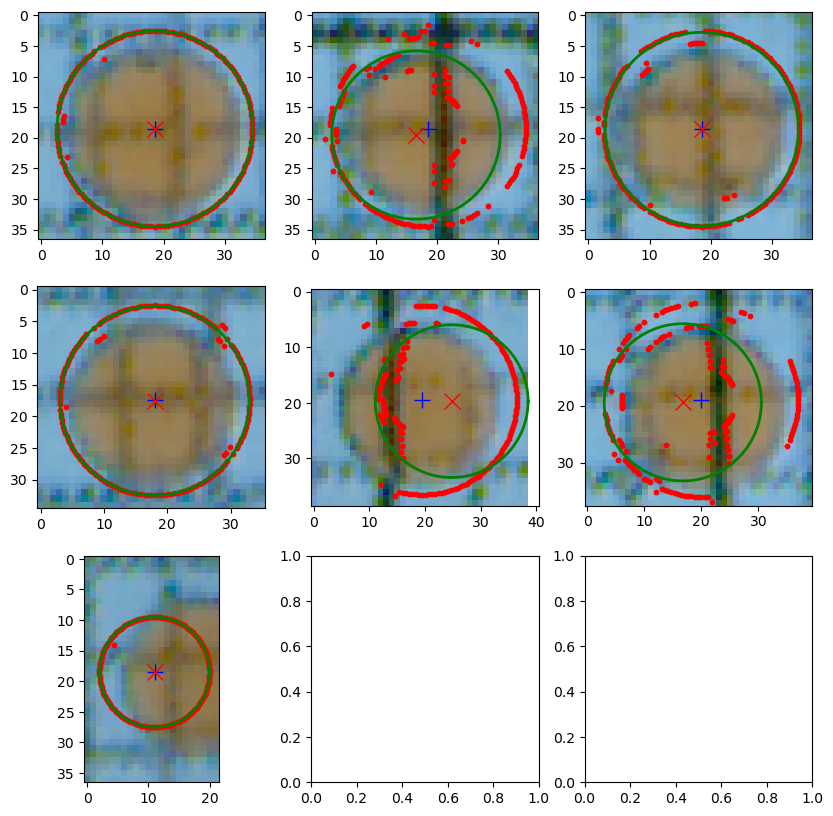

In [ ]:

from PIL import Image
im = Image.open(image_path2).convert("L")
color_im = np.array(Image.open(image_path2))

frame = np.array(im)
pred = model.predict(image_path2, verbose=False)

boxes = pred[0].boxes.xyxy.cpu().numpy()

results = []
fig,ax = plt.subplots(3,3)
ax = ax.flatten()



for idx,box in enumerate(boxes):

    x1, y1, x2, y2 = box
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    # ----------------------------------------------------
    # Padding around YOLO box
    # ----------------------------------------------------
    pad = 3

    x1p = max(0, x1 - pad)
    y1p = max(0, y1 - pad)

    x2p = min(frame.shape[1], x2 + pad)
    y2p = min(frame.shape[0], y2 + pad)

    roi = frame[y1p:y2p, x1p:x2p]
    color_roi = color_im[y1p:y2p, x1p:x2p]
    

    h, w = roi.shape

    xc0 = w/2
    yc0 = h/2

    xc, yc, R, pts = radial_circle_fit_1d(
        roi,
        center0=(xc0, yc0),
        n_angles=180,
        max_radius=int(min(h,w)/2),
        smooth_window=3
    )

    xc_global = xc + x1p
    yc_global = yc + y1p

    print(xc_global, yc_global, R)
    # ------------------------------------
    # Convert to full-frame coordinates
    # ------------------------------------
    xc_global = xc + x1p
    yc_global = yc + y1p

    # ------------------------------------
    # Radius statistics
    # ------------------------------------
    Ri = np.sqrt(
        (pts[:, 0] - xc)**2 +
        (pts[:, 1] - yc)**2
    )

    R_median = np.median(Ri)
    R_mean = np.mean(Ri)
    sigma_R = np.std(Ri)

    # ------------------------------------
    # Difference from YOLO center
    # ------------------------------------
    dx = xc - xc0
    dy = yc - yc0

    delta_center = np.sqrt(dx**2 + dy**2)

    # ------------------------------------
    # Save results
    # ------------------------------------
    results.append({
        # "frame": frame_number,
        "droplet": idx,
        "x": xc_global,
        "y": yc_global,
        "R": R,
        "R_median": R_median,
        "R_mean": R_mean,
        "sigma_R": sigma_R,
        "delta_center": delta_center,
        "n_boundary": len(pts)
    })
    ax[idx].imshow(color_roi, cmap='gray')

    # boundary points
    ax[idx].scatter(
        pts[:,0],
        pts[:,1],
        c='red',
        s=10,
        # label='Boundary'
    )

    # YOLO center
    ax[idx].plot(
        xc0,
        yc0,
        'b+',
        markersize=12,
        # label='YOLO'
    )

    # fitted center
    ax[idx].plot(
        xc,
        yc,
        'rx',
        markersize=12,
        # label='Fit'
    )

    # fitted circle
    theta = np.linspace(0, 2*np.pi, 300)

    ax[idx].plot(
        xc + R*np.cos(theta),
        yc + R*np.sin(theta),
        'g-',
        lw=2,
        # label='Circle'
    )

    # ax[idx].legend()
    # plt.show()
    
fig.set_size_inches(10,10)


   droplet           x           y          R   R_median     R_mean  \
0        0  357.500000  280.500000  17.000000  17.000000  17.000000   
1        1  326.490402  201.554424  16.972267  16.998161  16.972267   
2        2  296.500000  238.500000  17.000000  17.000000  17.000000   
3        3  461.000000  216.500000  16.000000  16.000000  16.000000   
4        4  178.500000  254.500000  18.000000  18.000000  18.000000   

        sigma_R  delta_center  n_boundary  
0  1.610738e-15      0.000000         180  
1  2.644260e-01      0.055264         180  
2  1.610738e-15      0.000000         180  
3  1.426011e-15      0.000000         180  
4  1.242039e-15      0.000000         180  
count     7.000000
mean     16.138895
std       2.793154
min      10.000000
25%      16.486134
50%      17.000000
75%      17.500000
max      18.000000
Name: R, dtype: float64
count    7.000000e+00
mean     3.777514e-02
std      9.994364e-02
min      9.455381e-16
25%      1.242039e-15
50%      1.426011e-15
7

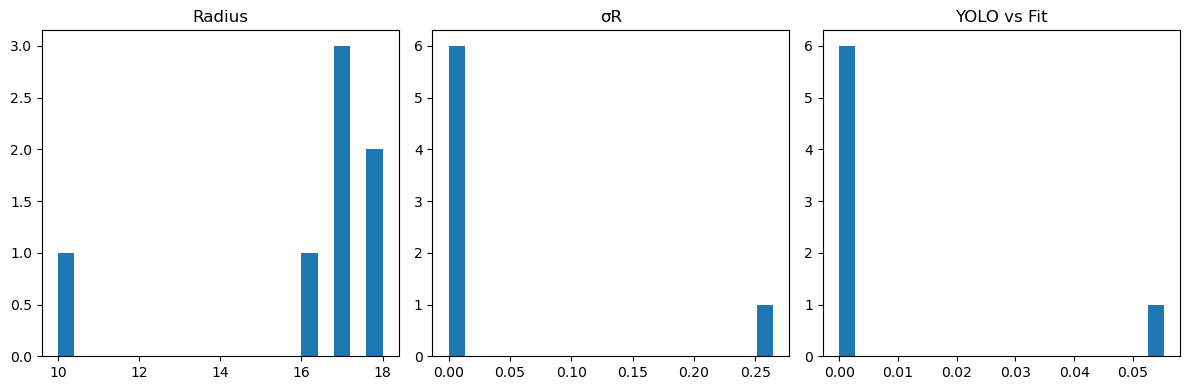

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

print(df.head())
print(df["R"].describe())
print(df["sigma_R"].describe())
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(df["R"], bins=20)
ax[0].set_title("Radius")

ax[1].hist(df["sigma_R"], bins=20)
ax[1].set_title("σR")

ax[2].hist(df["delta_center"], bins=20)
ax[2].set_title("YOLO vs Fit")

plt.tight_layout()
plt.show()
